✅ Loaded dataset from: /home/netsec1/Kathan/MaleVis 2 dataset/malevis_train_val_300x300/test
Processing QNI-CCP Model with 10 qubits...
  Loaded weights from qni_ccp-3_continued.pth
Processing Exp Model with 10 qubits...
  Loaded weights from exp-4_1_3.pth
Computing t-SNE (this may take a moment)...


/home/netsec1/myenv/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/netsec1/myenv/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the fol

✅ Plot saved successfully as: latent_features_tsne.pdf


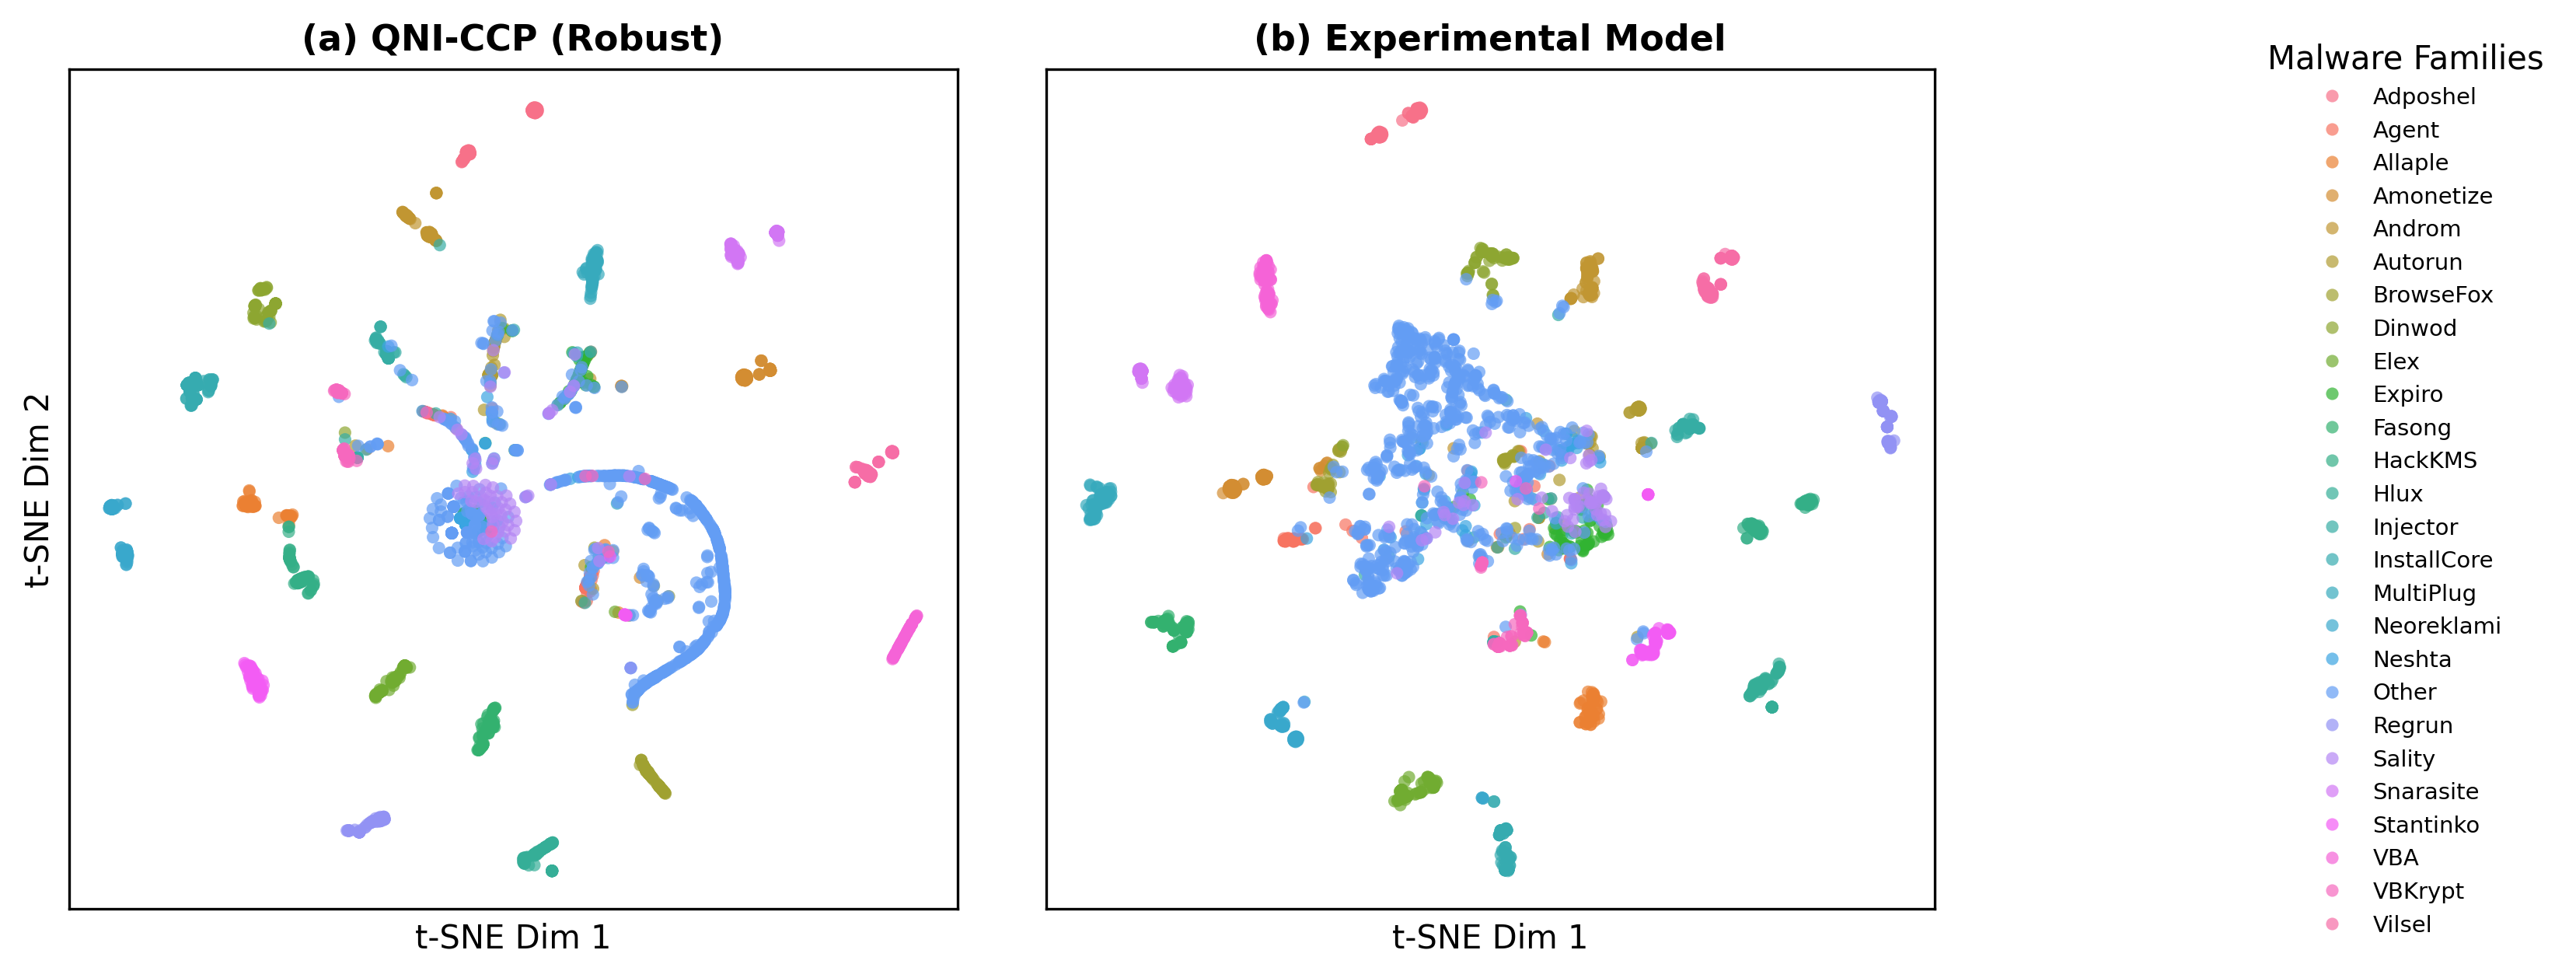

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
import pennylane as qml
from pennylane.qnn import TorchLayer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import os
import random

# ==========================================
# 1. CONFIGURATION & STYLE
# ==========================================

# Paths to your specific models
MODEL_1_PATH = "qni_ccp-3_continued.pth"  # 10 Qubit Model
MODEL_2_PATH = "exp-4_1_3.pth"            # 6 Qubit Model (Confirmed by checkpoint analysis)

# Dataset Path (Using your verified path)
DATA_PATH = '/home/netsec1/Kathan/MaleVis 2 dataset/malevis_train_val_300x300/test'
FALLBACK_PATH = '/home/netsec1/Kathan/MaleVis 2 dataset/malevis_train_val_300x300/val'

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
NUM_CLASSES = 26

# Professional Plotting Style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 7
plt.rcParams['figure.dpi'] = 300

# ==========================================
# 2. MODEL ARCHITECTURE (Dynamic Qubits)
# ==========================================

class FeatureReduce(nn.Module):
    def __init__(self, final_dim, dropout=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=2, padding=1),    
            nn.BatchNorm2d(8), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv2d(8, 16, 3, stride=2, padding=1),   
            nn.BatchNorm2d(16), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),  
            nn.BatchNorm2d(32), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  
            nn.BatchNorm2d(64), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), 
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 224, 3, stride=2, padding=1), 
            nn.BatchNorm2d(224), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))                 
        )
        self.fc_expand = nn.Linear(224, final_dim * 2)
        self.fc_project = nn.Linear(final_dim * 2, final_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc_expand(x))
        return self.fc_project(x)

class HybridQNN(nn.Module):
    def __init__(self, n_qubits, num_classes):
        super().__init__()
        self.n_qubits = n_qubits
        self.feature_extractor = FeatureReduce(final_dim=n_qubits)
        
        # --- Define Quantum Layer Dynamically based on n_qubits ---
        dev = qml.device("default.qubit", wires=n_qubits)

        @qml.qnode(dev, interface="torch", diff_method="backprop")
        def quantum_circuit(inputs, weights):
            # Angle Embedding
            for i in range(n_qubits):
                qml.RY(inputs[..., i], wires=i)
            # Basic Entangler Layers
            for l in range(weights.shape[0]):
                for i in range(n_qubits):
                    qml.RY(weights[l][i], wires=i)
                for i in range(n_qubits - 1):
                    qml.CNOT(wires=[i, i+1])
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

        weight_shapes = {"weights": (6, n_qubits)}
        self.q_layer = TorchLayer(quantum_circuit, weight_shapes)
        # ---------------------------------------------------------

        self.classifier = nn.Sequential(
            nn.Linear(n_qubits, 64), nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.tanh(x)
        q_out = self.q_layer(x) 
        return self.classifier(q_out)

    def get_latent_features(self, x):
        # Extract features right before the quantum layer
        x = self.feature_extractor(x)
        return torch.tanh(x)

# ==========================================
# 3. DATA LOADING & EXTRACTION
# ==========================================

def load_data():
    transform = transforms.Compose([
        transforms.Grayscale(1),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    
    path = DATA_PATH if os.path.exists(DATA_PATH) else FALLBACK_PATH
    if not os.path.exists(path):
        print(f"⚠️ Dataset not found at {DATA_PATH} or {FALLBACK_PATH}.")
        return None, None
    
    dataset = ImageFolder(path, transform=transform)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    print(f"✅ Loaded dataset from: {path}")
    return loader, dataset.classes

def extract_features(model_path, loader, name, n_qubits):
    print(f"Processing {name} with {n_qubits} qubits...")
    
    # Initialize the specific architecture for this model
    model = HybridQNN(n_qubits=n_qubits, num_classes=NUM_CLASSES).to(DEVICE)
    
    try:
        state_dict = torch.load(model_path, map_location=DEVICE)
        model.load_state_dict(state_dict)
        print(f"  Loaded weights from {model_path}")
    except FileNotFoundError:
        print(f"  ❌ File {model_path} not found! Skipping.")
        return None, None
    except RuntimeError as e:
        print(f"  ❌ Architecture mismatch for {name}: {e}")
        return None, None

    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            feats = model.get_latent_features(x)
            all_features.append(feats.cpu().numpy())
            all_labels.extend(y.numpy())

    return np.concatenate(all_features), np.array(all_labels)

# ==========================================
# 4. PLOTTING
# ==========================================

def plot_combined_tsne(features1, labels1, features2, labels2, class_names):
    print("Computing t-SNE (this may take a moment)...")
    
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    
    # Compute t-SNE for both
    tsne_1 = tsne.fit_transform(features1)
    tsne_2 = tsne.fit_transform(features2)
    
    # Create Figure
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    
    # Color Palette
    unique_labels = np.unique(labels1) # Assuming same classes in both
    palette = sns.color_palette("husl", len(unique_labels))
    
    # Plot 1: QNI-CCP
    sns.scatterplot(
        x=tsne_1[:, 0], y=tsne_1[:, 1], hue=labels1, palette=palette, 
        ax=axes[0], s=15, alpha=0.7, legend=False, linewidth=0
    )
    axes[0].set_title("(a) QNI-CCP (Robust)", fontweight='bold')
    axes[0].set_xticks([])
    axes[0].set_yticks([])
    axes[0].set_xlabel("t-SNE Dim 1")
    axes[0].set_ylabel("t-SNE Dim 2")
    
    # Plot 2: Experimental
    sns.scatterplot(
        x=tsne_2[:, 0], y=tsne_2[:, 1], hue=labels2, palette=palette, 
        ax=axes[1], s=15, alpha=0.7, legend=True, linewidth=0
    )
    axes[1].set_title("(b) Experimental Model", fontweight='bold')
    axes[1].set_xticks([])
    axes[1].set_yticks([])
    axes[1].set_xlabel("t-SNE Dim 1")
    axes[1].set_ylabel("") # Remove y-label for compactness
    
    # Handle Legend
    # Get handles/labels from axis 2
    handles, _ = axes[1].get_legend_handles_labels()
    # Map numeric labels back to class names
    legend_labels = [class_names[int(l)] for l in unique_labels]
    
    axes[1].legend_.remove() # Remove default internal legend
    
    # Create a unified external legend to save space
    fig.legend(handles, legend_labels, loc='center right', 
               bbox_to_anchor=(1.12, 0.5), ncol=1, frameon=False, 
               title="Malware Families")
    
    # Adjust layout to make room for legend and minimize white space
    plt.subplots_adjust(left=0.05, bottom=0.1, right=0.85, top=0.9, wspace=0.1)
    
    # Save
    save_path = "latent_features_tsne.pdf"
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    print(f"✅ Plot saved successfully as: {save_path}")
    # plt.show() # Uncomment if running locally with display

# ==========================================
# 5. MAIN EXECUTION
# ==========================================

if __name__ == "__main__":
    loader, class_names = load_data()
    
    if loader:
        # Extract features for Model 1 (10 Qubits)
        feats1, lbls1 = extract_features(MODEL_1_PATH, loader, "QNI-CCP Model", n_qubits=10)
        
        # Extract features for Model 2 (6 Qubits - Confirmed)
        feats2, lbls2 = extract_features(MODEL_2_PATH, loader, "Exp Model", n_qubits=10)
        
        if feats1 is not None and feats2 is not None:
            plot_combined_tsne(feats1, lbls1, feats2, lbls2, class_names)
        else:
            print("Could not load both models. Please check filenames and architectures.")

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
import numpy as np
import random
from torchvision.datasets import ImageFolder
from matplotlib import pyplot as plt
import pennylane as qml
from pennylane.qnn import TorchLayer
import matplotlib
from sklearn.manifold import TSNE
import os
from tqdm import tqdm

# Set matplotlib to use professional fonts for ACM papers
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']
matplotlib.rcParams['font.size'] = 10
matplotlib.rcParams['axes.labelsize'] = 10
matplotlib.rcParams['axes.titlesize'] = 11
matplotlib.rcParams['xtick.labelsize'] = 9
matplotlib.rcParams['ytick.labelsize'] = 9
matplotlib.rcParams['legend.fontsize'] = 9
matplotlib.rcParams['figure.titlesize'] = 11

# Set seeds for reproducibility
def seed_all(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_all(42)

# ========== DEVICE ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ========== PARAMETERS ==========
n_qubits = 10
batch_size = 16
num_classes = 26  # Changed from 25 to 26 to match adv2.pth
num_epochs = 50
patience = 7
learning_rate = 0.001

# ========== TRANSFORMS ==========
train_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

eval_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# ========== DATASET ==========
print("\n" + "="*60)
print("📂 LOADING DATASETS")
print("="*60)

train_dataset = ImageFolder('malevis_train_val_300x300/train', transform=train_transform)
val_dataset = ImageFolder('malevis_train_val_300x300/val', transform=eval_transform)
test_dataset = ImageFolder('malevis_train_val_300x300/test', transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

print(f"✓ Train samples: {len(train_dataset)}")
print(f"✓ Val samples: {len(val_dataset)}")
print(f"✓ Test samples: {len(test_dataset)}")
print(f"✓ Number of classes in dataset: {len(train_dataset.classes)}")

# Verify class count matches
actual_num_classes = len(train_dataset.classes)
if actual_num_classes != num_classes:
    print(f"⚠️  WARNING: Dataset has {actual_num_classes} classes but model expects {num_classes}")
    print(f"    Adjusting num_classes to match dataset...")
    num_classes = actual_num_classes

# ========== MODEL DEFINITIONS ==========

class FeatureReduce(nn.Module):
    def __init__(self, final_dim, dropout=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=2, padding=1),    # 224 -> 112
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv2d(8, 16, 3, stride=2, padding=1),   # 112 -> 56
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv2d(16, 32, 3, stride=2, padding=1),  # 56 -> 28
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # 28 -> 14
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv2d(64, 128, 3, stride=2, padding=1), # 14 -> 7
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 224, 3, stride=2, padding=1), # 7 -> 4
            nn.BatchNorm2d(224),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))                # 4x4 -> 1x1
        )
        self.fc_expand = nn.Linear(224, final_dim * 2)
        self.fc_project = nn.Linear(final_dim * 2, final_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc_expand(x))
        return self.fc_project(x)

# Quantum circuit
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)
    
    for l in range(weights.shape[0]):
        for i in range(n_qubits):
            qml.RY(weights[l][i], wires=i)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
    
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shapes = {"weights": (6, n_qubits)}

class HybridQNN(nn.Module):
    def __init__(self, n_qubits, num_classes):
        super().__init__()
        self.feature_extractor = FeatureReduce(final_dim=n_qubits)
        self.q_layer = TorchLayer(quantum_circuit, weight_shapes)
        self.classifier = nn.Sequential(
            nn.Linear(n_qubits, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.tanh(x)
        q_out = torch.stack([self.q_layer(f) for f in x])
        return self.classifier(q_out)

class ClassicalCNN(nn.Module):
    """
    Classical CNN with the same architecture as quantum model but without quantum layer
    """
    def __init__(self, n_qubits, num_classes):
        super().__init__()
        self.feature_extractor = FeatureReduce(final_dim=n_qubits)
        self.classifier = nn.Sequential(
            nn.Linear(n_qubits, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)
        )
    
    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.tanh(x)  # Apply same activation as quantum model
        return self.classifier(x)

# ========== TRAINING FUNCTIONS ==========

def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc="Training", leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.2f}%'})
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def train_classical_model(model, train_loader, val_loader, num_epochs, patience, device):
    """
    Train classical model with early stopping
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    
    print("\n" + "="*60)
    print("🚀 TRAINING CLASSICAL MODEL")
    print("="*60)
    print(f"Epochs: {num_epochs} | Early Stopping Patience: {patience}")
    print(f"Learning Rate: {learning_rate} | Batch Size: {batch_size}")
    print("="*60 + "\n")
    
    for epoch in range(num_epochs):
        # Training
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validation
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        
        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"✓ New best model saved (Val Loss: {val_loss:.4f})")
        else:
            patience_counter += 1
            print(f"⚠ Patience: {patience_counter}/{patience}")
            
            if patience_counter >= patience:
                print(f"\n🛑 Early stopping triggered at epoch {epoch+1}")
                break
    
    # Load best model
    model.load_state_dict(best_model_state)
    print(f"\n✅ Training completed! Best Val Loss: {best_val_loss:.4f}")
    
    # Save model
    save_path = "classical_model_trained.pth"
    torch.save(best_model_state, save_path)
    print(f"💾 Model saved to: {save_path}")
    
    return model

# ========== T-SNE VISUALIZATION FUNCTION ==========

def visualize_decision_boundaries_professional(model, test_loader, model_name="Model", 
                                               output_file="tsne_plot.pdf", 
                                               max_samples=2000):
    """
    Generate professional t-SNE visualization for ACM research papers.
    Creates a 4in x 4in PDF with publication-quality formatting.
    
    Args:
        model: The neural network model
        test_loader: DataLoader for test data
        model_name: Name of the model for the title
        output_file: Output PDF filename
        max_samples: Maximum number of samples to visualize (for performance)
    """
    model.eval()
    all_features = []
    all_labels = []
    
    print(f"Extracting features for {model_name}...")
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            
            # For quantum model - get features after quantum layer
            if hasattr(model, 'q_layer'):
                features = model.feature_extractor(x)
                features = torch.tanh(features)
                q_out = torch.stack([model.q_layer(f) for f in features])
                all_features.append(q_out.cpu())
            else:
                # For classical model - get features after feature extractor
                features = model.feature_extractor(x)
                features = torch.tanh(features)
                all_features.append(features.cpu())
                
            all_labels.append(y.cpu())
            
            # Limit samples for visualization
            if len(all_features) * x.size(0) >= max_samples:
                break
    
    features = torch.cat(all_features, 0)
    labels = torch.cat(all_labels, 0)
    
    # Limit to max_samples
    if features.size(0) > max_samples:
        indices = torch.randperm(features.size(0))[:max_samples]
        features = features[indices]
        labels = labels[indices]
    
    print(f"Running t-SNE on {features.size(0)} samples...")
    # Use t-SNE to reduce to 2D
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    features_2d = tsne.fit_transform(features.numpy())
    
    # Create figure with 4in x 4in size (ACM standard)
    fig = plt.figure(figsize=(4, 4), dpi=300)
    ax = fig.add_subplot(111)
    
    # Professional color palette (colorblind-friendly)
    unique_labels = np.unique(labels.numpy())
    n_classes = len(unique_labels)
    
    # Use professional colormap
    if n_classes <= 10:
        colors = plt.cm.tab10(np.linspace(0, 1, 10))[:n_classes]
    elif n_classes <= 20:
        colors = plt.cm.tab20(np.linspace(0, 1, 20))[:n_classes]
    else:
        colors = plt.cm.gist_ncar(np.linspace(0, 1, n_classes))
    
    # Create scatter plot with professional styling
    for idx, label in enumerate(unique_labels):
        mask = labels.numpy() == label
        ax.scatter(features_2d[mask, 0], features_2d[mask, 1], 
                  c=[colors[idx]], 
                  label=f'Class {label}',
                  s=8,  # Smaller points for cleaner look
                  alpha=0.7,
                  edgecolors='none',
                  rasterized=True)  # Rasterize for smaller file size
    
    # Professional formatting
    ax.set_xlabel('t-SNE Dimension 1', fontsize=10, fontweight='normal')
    ax.set_ylabel('t-SNE Dimension 2', fontsize=10, fontweight='normal')
    ax.set_title(f'{model_name}', fontsize=11, fontweight='normal', pad=10)
    
    # Remove top and right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Set professional tick parameters
    ax.tick_params(axis='both', which='major', labelsize=9, 
                   direction='out', length=4, width=0.8)
    
    # Add grid with subtle styling
    ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
    
    # Legend with professional styling (only if classes <= 10 for readability)
    if n_classes <= 10:
        ax.legend(loc='best', fontsize=8, frameon=True, 
                 fancybox=False, shadow=False, framealpha=0.9,
                 edgecolor='gray', ncol=1)
    
    # Tight layout to maximize space usage
    plt.tight_layout(pad=0.3)
    
    # Save as high-quality PDF
    print(f"Saving to {output_file}...")
    plt.savefig(output_file, format='pdf', dpi=300, 
                bbox_inches='tight', pad_inches=0.05)
    plt.close()
    
    print(f"✓ Professional t-SNE plot saved to {output_file}")
    
    return features_2d, labels

# ========== MAIN EXECUTION ==========

if __name__ == "__main__":
    # Create outputs directory
    output_dir = "outputs"
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"✓ Created directory: {output_dir}")
    
    # ========== LOAD QUANTUM MODEL ==========
    print("\n" + "="*60)
    print("⚛️  LOADING QUANTUM MODEL")
    print("="*60)
    
    quantum_model = HybridQNN(n_qubits, num_classes).to(device)
    try:
        checkpoint = torch.load("exp-4_1_3.pth", map_location=device)
        quantum_model.load_state_dict(checkpoint)
        print("✓ Quantum model loaded from adv2.pth")
        print(f"✓ Model configured for {num_classes} classes with {n_qubits} qubits")
    except Exception as e:
        print(f"❌ Error loading quantum model: {e}")
        exit(1)
    
    # ========== TRAIN CLASSICAL MODEL ==========
    print("\n" + "="*60)
    print("🎯 INITIALIZING CLASSICAL MODEL")
    print("="*60)
    
    classical_model = ClassicalCNN(n_qubits, num_classes).to(device)
    print(f"✓ Classical model created")
    print(f"✓ Total parameters: {sum(p.numel() for p in classical_model.parameters()):,}")

    #uncomment to train the classical model
    # # Train the classical model
    # classical_model = train_classical_model(
    #     classical_model, 
    #     train_loader, 
    #     val_loader, 
    #     num_epochs=num_epochs,
    #     patience=patience,
    #     device=device
    # )
    
    # ========== GENERATE T-SNE VISUALIZATIONS ==========
    print("\n" + "="*60)
    print("🎨 GENERATING PROFESSIONAL T-SNE VISUALIZATIONS")
    print("="*60)
    
    # Generate t-SNE plot for Quantum Model
    print("\n1️⃣ Generating Quantum Model t-SNE...")
    visualize_decision_boundaries_professional(
        quantum_model, 
        test_loader, 
        model_name="Hybrid QNN",
        output_file="outputs/quantum_model_tsne_4x4.pdf",
        max_samples=2000
    )
    
    # Generate t-SNE plot for Classical Model
    print("\n2️⃣ Generating Classical Model t-SNE...")
    visualize_decision_boundaries_professional(
        classical_model, 
        test_loader, 
        model_name="Classical CNN",
        output_file="outputs/classical_model_tsne_4x4.pdf",
        max_samples=2000
    )
    
    # ========== FINAL SUMMARY ==========
    print("\n" + "="*60)
    print("✅ COMPARISON COMPLETED SUCCESSFULLY!")
    print("="*60)
    print("\n📄 Output Files:")
    print("   • quantum_model_tsne_4x4.pdf")
    print("   • classical_model_tsne_4x4.pdf")
    print("   • classical_model_trained.pth")
    print("\n📏 Specifications:")
    print("   • Size: 4in × 4in (ACM standard)")
    print("   • Resolution: 300 DPI")
    print("   • Font: Times New Roman (ACM standard)")
    print("   • Format: PDF (publication-ready)")
    print("\n💡 Ready for inclusion in your ACM research paper!")
    print("="*60)

Using device: cuda

📂 LOADING DATASETS
✓ Train samples: 9947
✓ Val samples: 2149
✓ Test samples: 2130
✓ Number of classes in dataset: 26

⚛️  LOADING QUANTUM MODEL
✓ Quantum model loaded from adv2.pth
✓ Model configured for 26 classes with 10 qubits

🎯 INITIALIZING CLASSICAL MODEL
✓ Classical model created
✓ Total parameters: 365,920

🎨 GENERATING PROFESSIONAL T-SNE VISUALIZATIONS

1️⃣ Generating Quantum Model t-SNE...
Extracting features for Hybrid QNN...
Running t-SNE on 2000 samples...


/home/netsec1/myenv/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Saving to outputs/quantum_model_tsne_4x4.pdf...
✓ Professional t-SNE plot saved to outputs/quantum_model_tsne_4x4.pdf

2️⃣ Generating Classical Model t-SNE...
Extracting features for Classical CNN...
Running t-SNE on 2000 samples...


/home/netsec1/myenv/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Saving to outputs/classical_model_tsne_4x4.pdf...
✓ Professional t-SNE plot saved to outputs/classical_model_tsne_4x4.pdf

✅ COMPARISON COMPLETED SUCCESSFULLY!

📄 Output Files:
   • quantum_model_tsne_4x4.pdf
   • classical_model_tsne_4x4.pdf
   • classical_model_trained.pth

📏 Specifications:
   • Size: 4in × 4in (ACM standard)
   • Resolution: 300 DPI
   • Font: Times New Roman (ACM standard)
   • Format: PDF (publication-ready)

💡 Ready for inclusion in your ACM research paper!


In [11]:
'''
code to get entropy and other vlues
'''

import torch
import torch.nn.functional as F
import numpy as np
from scipy.stats import entropy

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
import numpy as np
import random
import os
from torchvision.datasets import ImageFolder
import pennylane as qml
from pennylane.qnn import TorchLayer
from tqdm import tqdm
from sklearn.utils.class_weight import compute_class_weight

# ========== SEEDING ==========
def seed_all(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_all(42)

# ========== DEVICE ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ========== CONFIGURATION ==========
n_qubits = 10
batch_size = 16
num_classes = 26
num_epochs = 70
lr = 0.0005

# ========== DATA TRANSFORMS ==========
train_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

eval_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# ========== DATASET LOADING ==========
TRAIN_PATH = '/home/netsec1/Kathan/MaleVis 2 dataset/malevis_train_val_300x300/train'
VAL_PATH   = '/home/netsec1/Kathan/MaleVis 2 dataset/malevis_train_val_300x300/val'
TEST_PATH  = '/home/netsec1/Kathan/MaleVis 2 dataset/malevis_train_val_300x300/test'

try:
    train_dataset = ImageFolder(TRAIN_PATH, transform=train_transform)
    val_dataset   = ImageFolder(VAL_PATH, transform=eval_transform)
    test_dataset  = ImageFolder(TEST_PATH, transform=eval_transform)
    print("** Dataset loaded successfully **")
    
except Exception as e:
    print(f"Error loading datasets: {e}")
    # Fallback for testing logic if paths don't exist
    os.makedirs("dummy_data/train/class1", exist_ok=True)
    os.makedirs("dummy_data/val/class1", exist_ok=True)
    os.makedirs("dummy_data/test/class1", exist_ok=True)
    train_dataset = ImageFolder("dummy_data/train", transform=train_transform)
    val_dataset = ImageFolder("dummy_data/val", transform=eval_transform)
    test_dataset = ImageFolder("dummy_data/test", transform=eval_transform)

# ========== CLASS WEIGHTS ==========

try:
    labels = [label for _, label in train_dataset.samples]
    class_weights = compute_class_weight(class_weight='balanced',
                                         classes=np.unique(labels),
                                         y=labels)
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    print(f"Class weights calculated: {class_weights_tensor[:5]}... (showing first 5)")
    
except:
    print("Warning: Could not calculate class weights. Using ones.")
    class_weights_tensor = torch.ones(num_classes).to(device)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

# ========== QUANTUM CIRCUIT ==========
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    # Angle Embedding
    for i in range(n_qubits):
        qml.RY(inputs[..., i], wires=i)
    
    # Basic Entangler Layers
    for l in range(weights.shape[0]):
        for i in range(n_qubits):
            qml.RY(weights[l][i], wires=i)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
    
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shapes = {"weights": (6, n_qubits)}

# ========== MODEL ARCHITECTURE ==========
class FeatureReduce(nn.Module):
    def __init__(self, final_dim, dropout=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=2, padding=1),    # 128 -> 64
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv2d(8, 16, 3, stride=2, padding=1),   # 64 -> 32
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv2d(16, 32, 3, stride=2, padding=1),  # 32 -> 16
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # 16 -> 8
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv2d(64, 128, 3, stride=2, padding=1), # 8 -> 4
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 224, 3, stride=2, padding=1), # 8 -> 4
            nn.BatchNorm2d(224),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))                # 4x4 -> 1x1
        )
        self.fc_expand = nn.Linear(224, final_dim * 2)
        self.fc_project = nn.Linear(final_dim * 2, final_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc_expand(x))
        return self.fc_project(x)

class HybridQNN(nn.Module):
    def __init__(self, n_qubits, num_classes):
        super().__init__()
        self.feature_extractor = FeatureReduce(final_dim=n_qubits)
        self.q_layer = TorchLayer(quantum_circuit, weight_shapes)
        
        self.classifier = nn.Sequential(
            nn.Linear(n_qubits, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.tanh(x)
        q_out = self.q_layer(x)
        return self.classifier(q_out)

# ========== DYNAMIC FOCAL LOSS ==========
class ScheduledFocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=0, reduction='mean'):
        super(ScheduledFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma # Init with 0 for pure CrossEntropy behavior
        self.reduction = reduction

    def forward(self, inputs, targets):
        # We always use the calculated class weights
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=class_weights_tensor)
        pt = torch.exp(-ce_loss)
        
        # When gamma=0, this term becomes 1, leaving just Weighted CE.
        # When gamma>0, this term down-weights easy examples.
        focal_loss = self.alpha * ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

def analyze_model_patterns(model, test_loader, device, model_name="Model"):
    """
    Computes pattern learning metrics: Entropy, Feature Variance, Unique Patterns, 
    High-confidence patterns, Average Confidence, and Confidence Std Dev.
    """
    model.eval()
    
    all_probs = []
    all_features = []
    all_preds = []
    
    print(f"📊 Analyzing patterns for {model_name}...")
    
    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)
            
            # 1. Get Features (Latent Space)
            if hasattr(model, 'q_layer'): # Quantum Model
                features = model.feature_extractor(x)
                features = torch.tanh(features)
                # For QNN, we often analyze the output of the quantum layer as the "rich" feature
                q_out = torch.stack([model.q_layer(f) for f in features]) 
                all_features.append(q_out.cpu())
                logits = model.classifier(q_out)
            else: # Classical Model
                features = model.feature_extractor(x)
                features = torch.tanh(features)
                all_features.append(features.cpu())
                logits = model.classifier(features)
            
            # 2. Get Probabilities and Predictions
            probs = F.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)
            
            all_probs.append(probs.cpu())
            all_preds.append(preds.cpu())

    # Concatenate all batches
    probs_tensor = torch.cat(all_probs, dim=0)
    features_tensor = torch.cat(all_features, dim=0)
    preds_tensor = torch.cat(all_preds, dim=0)
    
    # --- METRIC CALCULATIONS ---
    
    # 1. Average Confidence & Std Dev
    # Max probability for each sample
    max_probs, _ = torch.max(probs_tensor, dim=1)
    avg_confidence = max_probs.mean().item()
    confidence_std = max_probs.std().item()
    
    # 2. High-confidence patterns (>0.90)
    # Percentage of samples where model is >90% confident
    high_conf_count = (max_probs > 0.90).sum().item()
    high_conf_pct = (high_conf_count / probs_tensor.size(0)) * 100
    
    # 3. Feature Variance
    # Measures the spread of feature activations (lower = more balanced usage)
    # We calculate variance across the batch dimension, then mean across feature dimension
    feature_variance = torch.var(features_tensor, dim=0).mean().item()
    
    # 4. Unique Patterns
    # Number of unique classes predicted (measures diversity of predictions)
    unique_patterns = len(torch.unique(preds_tensor))
    
    # 5. Entropy
    # We calculate the entropy of the *marginal class distribution* (average usage of classes)
    # This tells us if the model uses all classes evenly (high entropy) or is biased (low entropy)
    avg_class_dist = probs_tensor.mean(dim=0).numpy() # Shape: [num_classes]
    model_entropy = entropy(avg_class_dist)

    return {
        "Entropy": model_entropy,
        "Feature Variance": feature_variance,
        "Unique Patterns": unique_patterns,
        "High-confidence patterns (>0.90)": high_conf_pct,
        "Average confidence": avg_confidence,
        "Confidence std. dev.": confidence_std
    }

# ==========================================
# MAIN EXECUTION
# ==========================================

# 1. Load Models
print("\n" + "="*50)
print("📥 LOADING MODELS FOR ANALYSIS")
print("="*50)

# Load Quantum Model
q_model = HybridQNN(n_qubits, num_classes).to(device)
try:
    # --- FIX: Changed filename from .ipynb to .pth ---
    q_checkpoint = torch.load("qni_ccp-3_continued.pth", map_location=device) # <--- FIXED
    
    # Handle dictionary loading vs direct loading
    if isinstance(q_checkpoint, dict) and "model_state_dict" in q_checkpoint:
        q_model.load_state_dict(q_checkpoint["model_state_dict"])
    else:
        q_model.load_state_dict(q_checkpoint)
        
    print("✓ Hybrid QNN loaded (qni_ccp_adv_model_epoch_23.pth)")
except FileNotFoundError:
    print("❌ Error: 'qni_ccp_adv_model_epoch_23.pth' not found. Please check the filename.")
except Exception as e:
    print(f"❌ Error loading QNN: {e}")

# Load Classical Model
c_model = ClassicalCNN(n_qubits, num_classes).to(device)
try:
    c_checkpoint = torch.load("classical_model_trained.pth", map_location=device)
    
    if isinstance(c_checkpoint, dict) and "model_state_dict" in c_checkpoint:
        c_model.load_state_dict(c_checkpoint["model_state_dict"])
    else:
        c_model.load_state_dict(c_checkpoint)
        
    print("✓ Classical CNN loaded (simple_classical_model.pth)")
except FileNotFoundError:
    print("❌ Error: 'simple_classical_model.pth' not found.")
except Exception as e:
    print(f"❌ Error loading Classical model: {e}")
    
# 2. Run Analysis
print("\n" + "="*50)
print("🔬 RUNNING PATTERN ANALYSIS")
print("="*50)

metrics_c = analyze_model_patterns(c_model, test_loader, device, "Classical CNN")
metrics_q = analyze_model_patterns(q_model, test_loader, device, "Hybrid QNN")

# 3. Print Comparison Table
print("\n" + "="*65)
print(f"{'Metric':<35} | {'Classical CNN':<12} | {'Hybrid QNN':<12}")
print("-" * 65)
print(f"{'Entropy':<35} | {metrics_c['Entropy']:.4f}       | {metrics_q['Entropy']:.4f}")
print(f"{'Feature Variance':<35} | {metrics_c['Feature Variance']:.4f}       | {metrics_q['Feature Variance']:.4f}")
print(f"{'Unique Patterns':<35} | {metrics_c['Unique Patterns']:<12} | {metrics_q['Unique Patterns']:<12}")
print(f"{'High-confidence patterns (>0.90)':<35} | {metrics_c['High-confidence patterns (>0.90)']:.1f}%       | {metrics_q['High-confidence patterns (>0.90)']:.1f}%")
print(f"{'Average confidence':<35} | {metrics_c['Average confidence']:.3f}        | {metrics_q['Average confidence']:.3f}")
print(f"{'Confidence std. dev.':<35} | {metrics_c['Confidence std. dev.']:.3f}        | {metrics_q['Confidence std. dev.']:.3f}")
print("=" * 65)

Using device: cuda
** Dataset loaded successfully **
Class weights calculated: tensor([1.0229, 1.0340, 1.0312, 1.0229, 1.0202], device='cuda:0')... (showing first 5)

📥 LOADING MODELS FOR ANALYSIS
✓ Hybrid QNN loaded (qni_ccp_adv_model_epoch_23.pth)
✓ Classical CNN loaded (simple_classical_model.pth)

🔬 RUNNING PATTERN ANALYSIS
📊 Analyzing patterns for Classical CNN...
📊 Analyzing patterns for Hybrid QNN...

Metric                              | Classical CNN | Hybrid QNN  
-----------------------------------------------------------------
Entropy                             | 3.0966       | 3.1137
Feature Variance                    | 0.3746       | 0.0269
Unique Patterns                     | 26           | 26          
High-confidence patterns (>0.90)    | 74.8%       | 61.3%
Average confidence                  | 0.885        | 0.819
Confidence std. dev.                | 0.204        | 0.244


In [2]:
'''
code to evaluate calssical model trained
'''

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
import numpy as np
import random
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from tqdm import tqdm
import os

# Set matplotlib to use professional fonts
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']
matplotlib.rcParams['font.size'] = 10

# Clear CUDA cache
try:
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print("✓ CUDA cache cleared")
except Exception as e:
    print(f"⚠️  CUDA warning: {e}")

# Set seeds for reproducibility
def seed_all(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_all(42)

# ========== DEVICE ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

# ========== PARAMETERS ==========
n_qubits = 10
batch_size = 16
num_classes = 26

# ========== TRANSFORMS ==========
eval_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# ========== DATASET ==========
print("="*60)
print("📂 LOADING TEST DATASET")
print("="*60)

test_dataset = ImageFolder('malevis_train_val_300x300/test', transform=eval_transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

print(f"✓ Test samples: {len(test_dataset)}")
print(f"✓ Number of classes: {len(test_dataset.classes)}")
print(f"✓ Class names: {test_dataset.classes}\n")

# ========== MODEL DEFINITION ==========

class FeatureReduce(nn.Module):
    def __init__(self, final_dim, dropout=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=2, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv2d(8, 16, 3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 224, 3, stride=2, padding=1),
            nn.BatchNorm2d(224),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc_expand = nn.Linear(224, final_dim * 2)
        self.fc_project = nn.Linear(final_dim * 2, final_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc_expand(x))
        return self.fc_project(x)

class ClassicalCNN(nn.Module):
    """
    Classical CNN with the same architecture as quantum model but without quantum layer
    """
    def __init__(self, n_qubits, num_classes):
        super().__init__()
        self.feature_extractor = FeatureReduce(final_dim=n_qubits)
        self.classifier = nn.Sequential(
            nn.Linear(n_qubits, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)
        )
    
    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.tanh(x)
        return self.classifier(x)

# ========== EVALUATION FUNCTIONS ==========

def evaluate_model(model, test_loader, device, class_names):
    """
    Comprehensive evaluation of the model
    """
    model.eval()
    
    all_predictions = []
    all_labels = []
    all_probs = []
    
    print("="*60)
    print("🔍 EVALUATING CLASSICAL MODEL")
    print("="*60)
    
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Testing"):
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_predictions)
    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels, all_predictions, average='weighted', zero_division=0
    )
    
    # Per-class metrics
    precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
        all_labels, all_predictions, average=None, zero_division=0
    )
    
    # Print overall metrics
    print("\n" + "="*60)
    print("📊 OVERALL PERFORMANCE METRICS")
    print("="*60)
    print(f"Overall Accuracy:  {accuracy*100:.2f}%")
    print(f"Weighted Precision: {precision*100:.2f}%")
    print(f"Weighted Recall:    {recall*100:.2f}%")
    print(f"Weighted F1-Score:  {f1*100:.2f}%")
    print("="*60)
    
    # Print per-class metrics
    print("\n" + "="*60)
    print("📈 PER-CLASS PERFORMANCE METRICS")
    print("="*60)
    print(f"{'Class':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
    print("-"*66)
    
    for i in range(len(class_names)):
        class_name = class_names[i] if i < len(class_names) else f"Class_{i}"
        print(f"{class_name:<20} {precision_per_class[i]*100:>10.2f}%  {recall_per_class[i]*100:>10.2f}%  "
              f"{f1_per_class[i]*100:>10.2f}%  {support_per_class[i]:>8}")
    
    print("="*60)
    
    # Detailed classification report
    print("\n" + "="*60)
    print("📋 DETAILED CLASSIFICATION REPORT")
    print("="*60)
    print(classification_report(
        all_labels, 
        all_predictions, 
        target_names=class_names if len(class_names) == len(np.unique(all_labels)) else None,
        digits=4,
        zero_division=0
    ))
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_predictions)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'predictions': all_predictions,
        'labels': all_labels,
        'probabilities': all_probs,
        'confusion_matrix': cm,
        'per_class_metrics': {
            'precision': precision_per_class,
            'recall': recall_per_class,
            'f1_score': f1_per_class,
            'support': support_per_class
        }
    }

def plot_confusion_matrix(cm, class_names, output_file='outputs/confusion_matrix.pdf'):
    """
    Plot confusion matrix with professional styling
    """
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 10), dpi=300)
    
    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names,
                cbar_kws={'label': 'Count'},
                ax=ax)
    
    ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax.set_title('Confusion Matrix - Classical CNN', fontsize=14, fontweight='bold', pad=20)
    
    # Rotate labels for better readability
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.savefig(output_file, format='pdf', dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"\n✓ Confusion matrix saved to: {output_file}")

def plot_per_class_metrics(per_class_metrics, class_names, output_file='outputs/per_class_metrics.pdf'):
    """
    Plot per-class precision, recall, and F1-score
    """
    fig, axes = plt.subplots(3, 1, figsize=(10, 12), dpi=300)
    
    x = np.arange(len(class_names))
    width = 0.6
    
    # Precision
    axes[0].bar(x, per_class_metrics['precision'] * 100, width, color='#2E86AB', alpha=0.8)
    axes[0].set_ylabel('Precision (%)', fontweight='bold')
    axes[0].set_title('Per-Class Precision', fontweight='bold', pad=10)
    axes[0].set_ylim([0, 105])
    axes[0].grid(axis='y', alpha=0.3, linestyle='--')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(class_names, rotation=45, ha='right')
    
    # Recall
    axes[1].bar(x, per_class_metrics['recall'] * 100, width, color='#A23B72', alpha=0.8)
    axes[1].set_ylabel('Recall (%)', fontweight='bold')
    axes[1].set_title('Per-Class Recall', fontweight='bold', pad=10)
    axes[1].set_ylim([0, 105])
    axes[1].grid(axis='y', alpha=0.3, linestyle='--')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(class_names, rotation=45, ha='right')
    
    # F1-Score
    axes[2].bar(x, per_class_metrics['f1_score'] * 100, width, color='#F18F01', alpha=0.8)
    axes[2].set_ylabel('F1-Score (%)', fontweight='bold')
    axes[2].set_title('Per-Class F1-Score', fontweight='bold', pad=10)
    axes[2].set_xlabel('Class', fontweight='bold')
    axes[2].set_ylim([0, 105])
    axes[2].grid(axis='y', alpha=0.3, linestyle='--')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(class_names, rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig(output_file, format='pdf', dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✓ Per-class metrics plot saved to: {output_file}")

def save_metrics_to_file(metrics, class_names, output_file='outputs/evaluation_metrics.txt'):
    """
    Save all metrics to a text file
    """
    with open(output_file, 'w') as f:
        f.write("="*70 + "\n")
        f.write("CLASSICAL CNN MODEL - EVALUATION METRICS\n")
        f.write("="*70 + "\n\n")
        
        f.write("OVERALL METRICS:\n")
        f.write("-"*70 + "\n")
        f.write(f"Overall Accuracy:   {metrics['accuracy']*100:.4f}%\n")
        f.write(f"Weighted Precision: {metrics['precision']*100:.4f}%\n")
        f.write(f"Weighted Recall:    {metrics['recall']*100:.4f}%\n")
        f.write(f"Weighted F1-Score:  {metrics['f1_score']*100:.4f}%\n")
        f.write("\n")
        
        f.write("PER-CLASS METRICS:\n")
        f.write("-"*70 + "\n")
        f.write(f"{'Class':<20} {'Precision':>12} {'Recall':>12} {'F1-Score':>12} {'Support':>10}\n")
        f.write("-"*70 + "\n")
        
        per_class = metrics['per_class_metrics']
        for i in range(len(class_names)):
            class_name = class_names[i] if i < len(class_names) else f"Class_{i}"
            f.write(f"{class_name:<20} {per_class['precision'][i]*100:>11.2f}% "
                   f"{per_class['recall'][i]*100:>11.2f}% "
                   f"{per_class['f1_score'][i]*100:>11.2f}% "
                   f"{per_class['support'][i]:>10}\n")
        
        f.write("\n")
        f.write("="*70 + "\n")
        
        # Confusion matrix
        f.write("\nCONFUSION MATRIX:\n")
        f.write("-"*70 + "\n")
        cm = metrics['confusion_matrix']
        
        # Header
        f.write(f"{'True/Pred':<15}")
        for name in class_names:
            f.write(f"{name[:10]:>12}")
        f.write("\n")
        f.write("-"*70 + "\n")
        
        # Rows
        for i, name in enumerate(class_names):
            f.write(f"{name[:15]:<15}")
            for j in range(len(class_names)):
                f.write(f"{cm[i][j]:>12}")
            f.write("\n")
        
        f.write("\n" + "="*70 + "\n")
    
    print(f"✓ Detailed metrics saved to: {output_file}")

# ========== MAIN EXECUTION ==========

if __name__ == "__main__":
    # Create outputs directory
    output_dir = "outputs"
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Load the trained classical model
    print("="*60)
    print("📥 LOADING TRAINED CLASSICAL MODEL")
    print("="*60)
    
    model = ClassicalCNN(n_qubits, num_classes).to(device)
    
    try:
        checkpoint = torch.load("classical_model_trained.pth", map_location=device)
        model.load_state_dict(checkpoint)
        print("✓ Classical model loaded from classical_model_trained.pth")
        print(f"✓ Model configured for {num_classes} classes with {n_qubits} features\n")
    except Exception as e:
        print(f"❌ Error loading model: {e}")
        print("   Make sure you have trained the model first using the training script.")
        exit(1)
    
    # Get class names
    class_names = test_dataset.classes
    
    # Evaluate the model
    metrics = evaluate_model(model, test_loader, device, class_names)
    
    # Generate visualizations
    print("\n" + "="*60)
    print("📊 GENERATING VISUALIZATIONS")
    print("="*60)
    
    plot_confusion_matrix(metrics['confusion_matrix'], class_names)
    plot_per_class_metrics(metrics['per_class_metrics'], class_names)
    
    # Save metrics to file
    save_metrics_to_file(metrics, class_names)
    
    # Final summary
    print("\n" + "="*60)
    print("✅ EVALUATION COMPLETED SUCCESSFULLY!")
    print("="*60)
    print("\n📄 Generated Files:")
    print("   • outputs/evaluation_metrics.txt     - Detailed metrics report")
    print("   • outputs/confusion_matrix.pdf       - Confusion matrix heatmap")
    print("   • outputs/per_class_metrics.pdf      - Per-class performance charts")
    print("\n💡 All files are publication-ready!")
    print("="*60)

✓ CUDA cache cleared
Using device: cuda

📂 LOADING TEST DATASET
✓ Test samples: 2130
✓ Number of classes: 26
✓ Class names: ['Adposhel', 'Agent', 'Allaple', 'Amonetize', 'Androm', 'Autorun', 'BrowseFox', 'Dinwod', 'Elex', 'Expiro', 'Fasong', 'HackKMS', 'Hlux', 'Injector', 'InstallCore', 'MultiPlug', 'Neoreklami', 'Neshta', 'Other', 'Regrun', 'Sality', 'Snarasite', 'Stantinko', 'VBA', 'VBKrypt', 'Vilsel']

📥 LOADING TRAINED CLASSICAL MODEL
✓ Classical model loaded from classical_model_trained.pth
✓ Model configured for 26 classes with 10 features

🔍 EVALUATING CLASSICAL MODEL


Testing: 100%|██████████| 134/134 [00:02<00:00, 49.75it/s]



📊 OVERALL PERFORMANCE METRICS
Overall Accuracy:  81.74%
Weighted Precision: 88.66%
Weighted Recall:    81.74%
Weighted F1-Score:  82.90%

📈 PER-CLASS PERFORMANCE METRICS
Class                Precision    Recall       F1-Score     Support   
------------------------------------------------------------------
Adposhel                 100.00%      100.00%      100.00%        60
Agent                     75.56%       68.00%       71.58%        50
Allaple                   81.25%       98.11%       88.89%        53
Amonetize                 98.33%       96.72%       97.52%        61
Androm                    58.82%       96.77%       73.17%        62
Autorun                   76.67%       75.41%       76.03%        61
BrowseFox                 81.16%       93.33%       86.82%        60
Dinwod                    98.39%       98.39%       98.39%        62
Elex                      98.39%       98.39%       98.39%        62
Expiro                    59.34%       85.71%       70.13%        63
F